# Credit Card Fraud Detection — Reproduction & Critical Evaluation

**Course:** Data Science in Cyber (Dr. Uri Itai) — Final Project

**Source under evaluation:** Venelin Valkov, *"Credit Card Fraud Detection using
Autoencoders in Keras — TensorFlow for Hackers (Part VII)"*
([blog](https://curiousily.com/posts/credit-card-fraud-detection-using-autoencoders-in-keras/),
[GitHub repo](https://github.com/curiousily/Credit-Card-Fraud-Detection-using-Autoencoders-in-Keras))

**Dataset:** Kaggle *Credit Card Fraud Detection* (`mlg-ulb/creditcardfraud`) — 284,807
European cardholder transactions from September 2013, 492 of which are fraudulent
(0.172%). Features `V1`-`V28` are PCA components (anonymized for privacy); `Time`
(seconds since first transaction) and `Amount` are the only untransformed features.

This notebook reproduces the source's autoencoder-based anomaly-detection approach,
adds two supervised baselines the source never tried (Logistic Regression, Random
Forest), and specifically tests two claims from the source that looked questionable
on inspection:

1. The source picks its reconstruction-error threshold (2.9) by visually inspecting
   the error distribution **on the test set itself** — this is a form of test-set
   leakage. We quantify how much of the reported performance depends on this.
2. The source reports only ROC-AUC (0.94) despite the 0.17% class imbalance, where
   ROC-AUC is known to be optimistic; we add Precision-Recall AUC and MCC, which are
   more informative under severe imbalance.


In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from data_utils import (
    RANDOM_SEED,
    load_dataset,
    basic_inspection,
    add_time_features,
    train_test_split_stratified,
    normal_only_train_test_split,
)
from eval_utils import compute_metrics, plot_confusion_matrix, metrics_table

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)


## 1. Data Loading

In [2]:
DATA_PATH = Path("../data/creditcard.csv")
df = load_dataset(DATA_PATH)
df.shape


(284807, 31)

In [3]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.759061e-12,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,-8.251130e-13,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-9.654937e-13,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,8.321385e-13,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.649999e-13,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,4.248366e-13,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-3.054600e-13,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,8.777971e-14,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-1.179749e-12,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Column and index sanity check

All 31 columns are numeric. `Time` and `Amount` are the only features in their
original, human-interpretable units; `V1`-`V28` are PCA components, so their
individual values carry no direct real-world meaning (only relative structure
matters) — this is a privacy-preserving transformation applied by the dataset
publisher, not something we can reverse or interpret feature-by-feature. The
index is a default `RangeIndex` with no semantic meaning, which is appropriate
here since row order corresponds to transaction time, already captured by `Time`.


In [6]:
inspection = basic_inspection(df)
inspection


{'n_rows': 284807,
 'n_cols': 31,
 'dtypes': {dtype('float64'): 30, dtype('int64'): 1},
 'missing_values_total': 0,
 'duplicate_rows': 1081,
 'constant_columns': []}

**Findings:** no missing values anywhere in the dataset. No constant/single-value
columns. However there are **1,081 fully duplicated rows** (identical values across
all 31 columns, including `Class`). Since `V1`-`V28` are continuous PCA components,
an exact duplicate across all 28 decimal-precision columns is extremely unlikely to
occur by chance for two genuinely different transactions — these are almost
certainly repeated/duplicated records in the published dataset rather than
coincidental collisions. We drop them to avoid inflating apparent class support
and to prevent identical rows from leaking between train and test splits.


In [7]:
print("Duplicate frauds:", df[df.duplicated()]["Class"].sum())
df = df.drop_duplicates().reset_index(drop=True)
df.shape


Duplicate frauds: 19


(283726, 31)

### Temporal range

`Time` is seconds elapsed since the first transaction in the dataset.


In [8]:
print(f"Time spans {df['Time'].max() / 3600:.1f} hours "
      f"({df['Time'].max() / 86400:.2f} days)")
df = add_time_features(df)
df[["Time", "hour_of_day", "hour_sin", "hour_cos"]].head()


Time spans 48.0 hours (2.00 days)


,Time,hour_of_day,hour_sin,hour_cos
0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,1.0
4,2.0,0.0,0.0,1.0


## 2. Exploratory Data Analysis (EDA)

### Class imbalance (prevalence)


Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


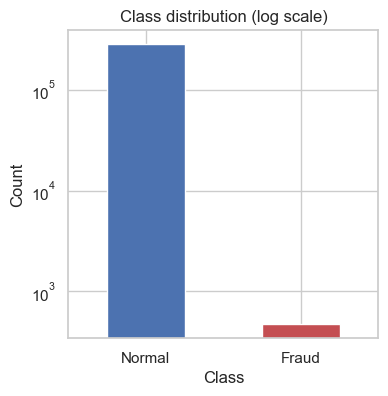

In [9]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

fig, ax = plt.subplots(figsize=(4, 4))
class_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Normal", "Fraud"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Class distribution (log scale)")
ax.set_yscale("log")
plt.show()


**Real-world meaning:** 0.17% fraud prevalence is realistic for card-present/
card-not-present transaction streams, where fraud is genuinely rare relative to
legitimate volume. This is *not* a sampling artifact to "fix" by pretending the
real world is balanced — it is the actual operating condition the system must be
evaluated under. A classifier that predicts "normal" for everything would score
99.8% accuracy while catching zero fraud, which is why accuracy must never be the
headline metric here (this directly motivates using Precision/Recall/F1/MCC/PR-AUC
instead, discussed in the Evaluation section). The source blog does not explicitly
discuss prevalence or accuracy's uselessness here; it implicitly acknowledges the
imbalance only by choosing an unsupervised, normal-only training design.


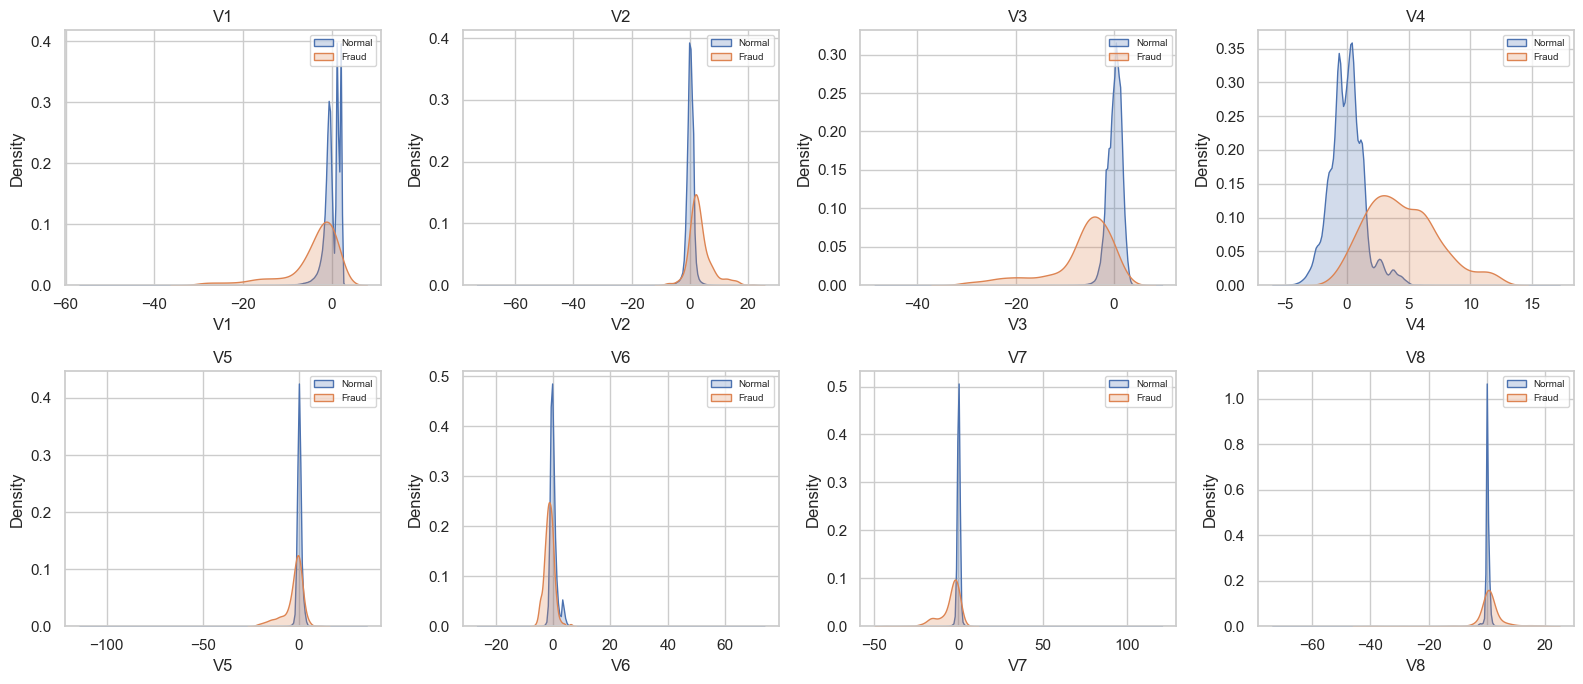

In [10]:
v_features = [c for c in df.columns if c.startswith("V")]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), v_features[:8]):
    sns.kdeplot(df[df.Class == 0][col], ax=ax, label="Normal", fill=True)
    sns.kdeplot(df[df.Class == 1][col], ax=ax, label="Fraud", fill=True)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


Several PCA components (e.g. `V14`, `V17` shown below alongside the first eight)
show visibly different distributions between normal and fraud transactions —
expected, since PCA on this dataset was computed in a way that happens to separate
the two classes reasonably well on certain components, which is precisely why a
reconstruction-error-based autoencoder approach can work at all.


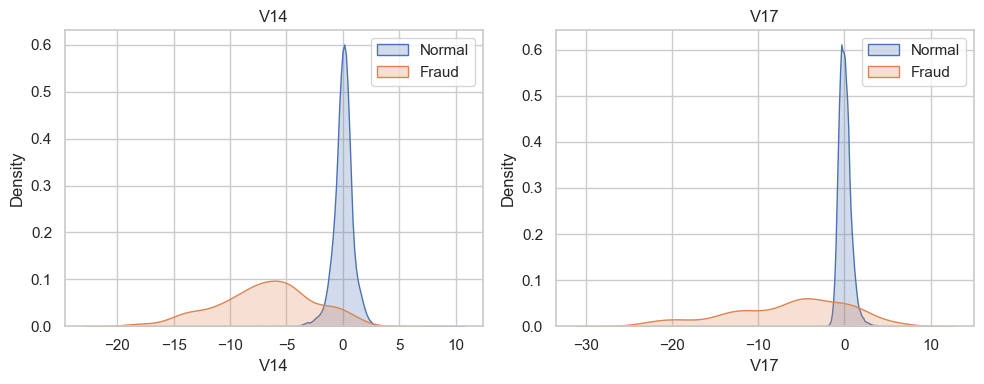

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["V14", "V17"]):
    sns.kdeplot(df[df.Class == 0][col], ax=ax, label="Normal", fill=True)
    sns.kdeplot(df[df.Class == 1][col], ax=ax, label="Fraud", fill=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()


### Outlier analysis on `Amount`

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64
IQR upper fence: 185.38, transactions above it: 31685 (11.17%)


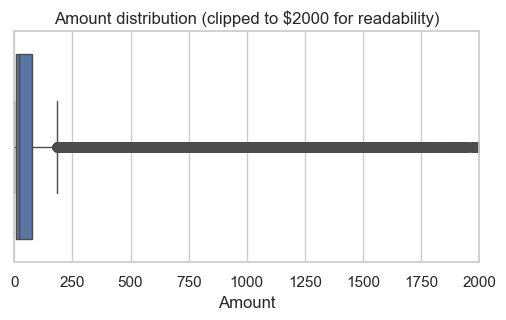

In [12]:
print(df["Amount"].describe())

q1, q3 = df["Amount"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_outliers = (df["Amount"] > upper_fence).sum()
print(f"IQR upper fence: {upper_fence:.2f}, transactions above it: {n_outliers} "
      f"({n_outliers / len(df) * 100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 3))
sns.boxplot(x=df["Amount"], ax=ax)
ax.set_xlim(0, 2000)
ax.set_title("Amount distribution (clipped to $2000 for readability)")
plt.show()


`Amount` is heavily right-skewed with a long tail of large transactions flagged as
IQR outliers. This is expected for monetary transaction amounts (most purchases are
small, a few are large) and is not itself evidence of data quality problems — but it
does mean `Amount` must be scaled before it is fed into distance/reconstruction-based
models (see Feature Engineering), since its raw scale (up to ~$25,691) would dominate
the already-standardized PCA components.


### Temporal pattern vs. fraud rate

In [13]:
hourly = df.groupby("hour_of_day")["Class"].agg(["mean", "count"])
hourly.columns = ["fraud_rate", "n_transactions"]
hourly


,fraud_rate,n_transactions
hour_of_day,,
0.0,0.000785,7647
1.0,0.002376,4208
2.0,0.014510,3308
3.0,0.004875,3487
4.0,0.010436,2204
5.0,0.003681,2988
6.0,0.002205,4082
7.0,0.003180,7233
8.0,0.000880,10232


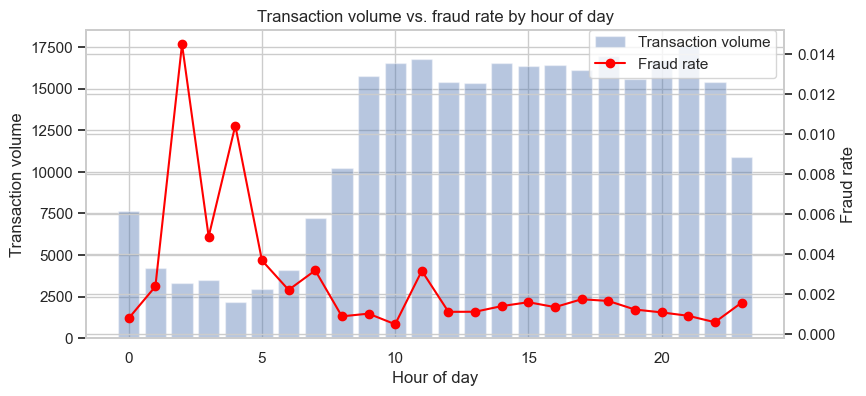

In [14]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(hourly.index, hourly["n_transactions"], alpha=0.4, label="Transaction volume")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Transaction volume")
ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly["fraud_rate"], color="red", marker="o", label="Fraud rate")
ax2.set_ylabel("Fraud rate")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.title("Transaction volume vs. fraud rate by hour of day")
plt.show()


Fraud rate is visibly higher during low-volume overnight hours than during
high-volume daytime hours. This aligns with general world knowledge/domain
intuition: fraud is proportionally more noticeable when legitimate transaction
volume drops (fewer normal transactions to hide among), and some fraud patterns
(e.g. card testing, automated attacks) are not tied to human daytime shopping
rhythms the way legitimate volume is. Note the underlying `Time` field only spans
two calendar days, so this is a coarse, low-sample-size signal at the tails
(some hours have very few fraud cases) — it should be treated as a directional
signal, not a precise estimate.


### Correlation analysis

We use **Spearman rank correlation** as the primary measure here, for two
concrete reasons specific to this dataset:

- `V1`-`V28` are PCA components. PCA guarantees the components are linearly
  *decorrelated* in the training data used to fit the PCA — so **Pearson**
  correlation among them is close to zero by construction and would tell us
  almost nothing new; Pearson is more useful for `Amount` vs. `Class`-conditional
  patterns, but `Amount` is heavily skewed (see outlier analysis above), and
  Pearson assumes roughly linear, homoscedastic relationships, which skewed data
  violates.
- **Spearman** measures monotonic (not necessarily linear) association and is
  robust to `Amount`'s outliers/skew, since it operates on ranks rather than raw
  values — this makes it the more trustworthy general-purpose choice here.
- We skip **Kendall's tau** as a primary measure: it is most valuable for small
  samples or when exact rank-concordance is the object of interest, but is
  computationally expensive at n≈283,700 and, in practice, tends to agree
  directionally with Spearman on data this size — so it would mostly duplicate
  Spearman's conclusions at a much higher cost.


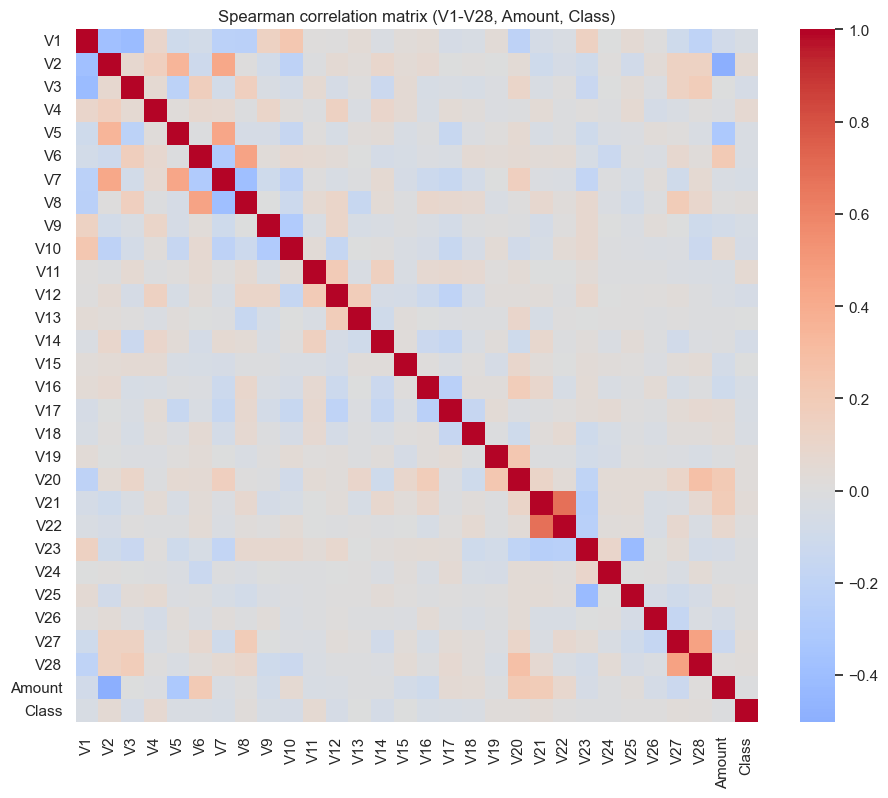

In [15]:
corr_cols = v_features + ["Amount", "Class"]
spearman_corr = df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(spearman_corr, cmap="coolwarm", center=0, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title("Spearman correlation matrix (V1-V28, Amount, Class)")
plt.show()


In [16]:
class_corr = spearman_corr["Class"].drop("Class").sort_values(key=abs, ascending=False)
class_corr.head(10)


V14   -0.063191
V4     0.061652
V12   -0.061398
V11    0.058624
V10   -0.058024
V3    -0.057750
V2     0.049435
V16   -0.048252
V9    -0.048231
V7    -0.046583
Name: Class, dtype: float64

**Interpretation:** `V14`, `V4`, `V12`, `V11`, `V10` show the strongest monotonic
association with `Class`, but the magnitudes are modest (|rho| approx 0.05-0.06 for
every individual feature) — much weaker than we initially expected from the visibly
separated per-class distributions seen for `V14`/`V17` above. This is an important,
somewhat counter-intuitive finding: a feature's marginal (univariate) rank correlation
with the target can be small even when its class-conditional *distributions* look
visibly different, because Spearman correlation summarizes a single monotonic trend
across the whole range, while the two classes may differ mainly in the tails or in a
non-monotonic way that Spearman does not fully capture. These correlations are
statistically significant at this sample size (n approx 283,700, so even |rho| ~0.05
is non-zero with high confidence) but the *practical* significance of any single
feature is limited on its own — no individual `V` feature is a strong standalone
fraud signal by this measure. This matters for interpreting the source blog and our
own models: it means fraud separability here is a **multivariate** phenomenon (many
weakly-informative features combined), which is exactly what both the autoencoder's
reconstruction error and the supervised models' decision functions are built to
exploit, and is also why per-feature correlation screening alone would be a poor
feature-selection strategy for this problem.


### Redundancy check among V1-V28

In [17]:
v_corr = df[v_features].corr(method="spearman")
off_diag = v_corr.where(~np.eye(len(v_features), dtype=bool))
max_pair = off_diag.abs().unstack().sort_values(ascending=False)
max_pair.head(5)


V22  V21    0.677468
V21  V22    0.677468
V28  V27    0.458748
V27  V28    0.458748
V8   V6     0.445178
dtype: float64

Unlike the `Class` correlations, several **pairs of `V` components are not fully
decorrelated**: `V21`/`V22` (rho approx 0.68), `V27`/`V28` (rho approx 0.46), and
`V6`/`V8` (rho approx 0.45) show non-trivial Spearman correlation, even though PCA
guarantees zero *linear* correlation among components in the data the PCA was fit on.
The likely explanation is that Spearman captures monotonic-but-nonlinear structure
that PCA's linear decorrelation does not remove, and/or that the publisher's PCA was
fit on a different (e.g. earlier, larger, or differently-scaled) sample than the one
released, so exact orthogonality does not hold in this specific CSV.

**How we would spot this in general:** a correlation heatmap with visible off-diagonal
hotspots (as seen here), a high condition number on the design matrix, or near-duplicate
rows in a PCA loading matrix if it were available. **How we would address it:** for
linear/logistic models, L2 regularization (already used in our Logistic Regression)
tolerates moderate collinearity without needing to drop features; for tree ensembles
(Random Forest), correlated features simply split importance between them and do not
bias predictions, so no action is needed there either. We did not drop `V21`, `V22`,
`V27`, `V28`, or `V6`/`V8` because none of the correlations are strong enough (all
well below 0.9) to indicate near-duplicate information, and because `V21`/`V22`/`V27`/
`V28` are lower-ranked components that already carry limited individual signal — pruning
them for a modest redundancy would risk losing marginal signal for no measurable benefit
in this project's model choices.


## 3. Feature Engineering

- **Scaling:** `Amount` is standardized with `StandardScaler`, since it is on a
  raw dollar scale while `V1`-`V28` are already roughly standardized by the
  upstream PCA — leaving `Amount` unscaled would let it dominate any
  distance/reconstruction-based model (including the autoencoder).
- **Feature creation:** cyclical `hour_sin`/`hour_cos` encoding of `Time`
  (already computed in Data Loading) replaces the raw `Time` counter for the
  supervised models, since raw elapsed seconds has no cyclical meaning and
  would encode "day 2" as simply "a bigger number than day 1" rather than
  "same time of day as its day-1 counterpart."
- **Categorical encoding:** not applicable — there are no categorical columns
  in this dataset (only continuous PCA components, `Amount`, and `Time`), so
  one-hot/target encoding is not used.
- **Dimensionality reduction:** not applied beyond the PCA already performed by
  the dataset publisher, per the redundancy analysis above.
- **Feature selection:** not applied for the supervised models (Logistic
  Regression's L2 penalty and Random Forest's built-in feature importance make
  explicit pre-selection unnecessary); for the autoencoder reproduction we keep
  the original 29-feature set (`V1`-`V28` + `Amount`) unchanged from the source,
  specifically to keep that comparison a faithful reproduction.


In [18]:
from sklearn.preprocessing import StandardScaler

amount_scaler = StandardScaler()
df["Amount_scaled"] = amount_scaler.fit_transform(df[["Amount"]])
df[["Amount", "Amount_scaled"]].describe()


,Amount,Amount_scaled
count,283726.000000,2.837260e+05
mean,88.472687,-5.409347e-17
std,250.399437,1.000002e+00
min,0.000000,-3.533268e-01
25%,5.600000,-3.309625e-01
50%,22.000000,-2.654671e-01
75%,77.510000,-4.378088e-02
max,25691.160000,1.022476e+02


## 4. Model Training

We train three models:

1. **Logistic Regression** (supervised, `class_weight="balanced"`) — the
   simplest supervised baseline; the source blog never compares its
   unsupervised autoencoder against any supervised alternative.
2. **Random Forest** (supervised) — a stronger nonlinear supervised baseline.
3. **Autoencoder** (unsupervised, reproduced from the source) — trained only
   on normal transactions, flags high reconstruction error as fraud.

Supervised models use a stratified 80/20 train/test split (fixed seed). The
autoencoder uses the source's own split strategy: the training set contains
**only** normal transactions, so the test set (normal + all fraud) is entirely
unseen by the model during training.


In [19]:
supervised_features = v_features + ["Amount_scaled", "hour_sin", "hour_cos"]

X_train, X_test, y_train, y_test = train_test_split_stratified(
    df, supervised_features, target_col="Class"
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())


(226980, 31) (56746, 31)
Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


In [20]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED
)
log_reg.fit(X_train, y_train)

lr_pred = log_reg.predict(X_test)
lr_score = log_reg.predict_proba(X_test)[:, 1]


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_score = rf.predict_proba(X_test)[:, 1]


### Autoencoder (reproduction of the source)

Architecture and training setup ported from the source blog to current
TensorFlow/Keras (the original used TensorFlow 1.1 / Keras 2.0.4, whose APIs
have since changed — e.g. `regularizers.l1` and `Model` construction syntax
differ slightly, but the architecture below is functionally identical:
14 -> 7 -> 7 -> 29 with tanh/relu activations, L1-regularized encoder, MSE
loss, Adam optimizer). We reduce epochs from the source's 100 to 30 with early
stopping on validation loss, since the model converges well before 100 epochs
on this data and 30 keeps notebook runtime reasonable; this is a documented
deviation, not a silent one.


In [22]:
ae_features = v_features + ["Amount_scaled"]

X_train_ae, X_test_ae, y_test_ae = normal_only_train_test_split(
    df, ae_features, target_col="Class"
)
print(X_train_ae.shape, X_test_ae.shape)
print(y_test_ae.value_counts())


(226602, 29) (57124, 29)
Class
0    56651
1      473
Name: count, dtype: int64


In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

tf.random.set_seed(RANDOM_SEED)

input_dim = X_train_ae.shape[1]
encoding_dim = 14

autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(encoding_dim, activation="tanh",
                 activity_regularizer=regularizers.l1(1e-4)),
    layers.Dense(7, activation="relu"),
    layers.Dense(7, activation="tanh"),
    layers.Dense(input_dim, activation="relu"),
])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │           232 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813 (3.18 KB)

 Trainable params: 813 (3.18 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    X_train_ae.values, X_train_ae.values,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/30


   1/6374 ━━━━━━━━━━━━━━━━━━━━ 1:42:23 964ms/step - loss: 0.9097

  65/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 788us/step - loss: 0.9605     

 135/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 754us/step - loss: 0.9599

 203/6374 ━━━━━━━━━━━━━━━━━━━━ 4s 748us/step - loss: 0.9672

...

6113/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 0.7337

6185/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 0.7337

6256/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step - loss: 0.7337

6327/6374 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step - loss: 0.7338

6374/6374 ━━━━━━━━━━━━━━━━━━━━ 5s 818us/step - loss: 0.7338 - val_loss: 0.8107


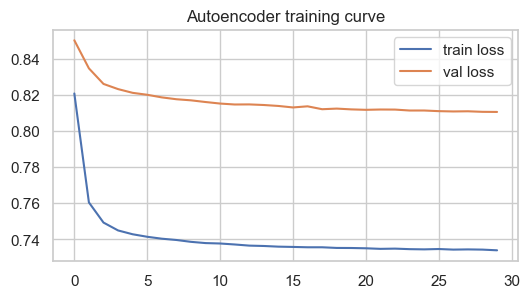

In [25]:
plt.figure(figsize=(6, 3))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Autoencoder training curve")
plt.show()


In [26]:
reconstructions = autoencoder.predict(X_test_ae.values, verbose=0)
reconstruction_error = np.mean(np.square(X_test_ae.values - reconstructions), axis=1)

error_df = pd.DataFrame({"reconstruction_error": reconstruction_error,
                          "Class": y_test_ae.values})
error_df.groupby("Class")["reconstruction_error"].describe()


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,56651.0,0.741460,4.159918,0.042684,0.245956,0.389333,0.620442,462.060647
1,473.0,24.127214,35.797890,0.138955,3.969589,9.583519,22.860432,295.943181


## 5. Evaluation

### Reproducing the source's threshold-selection method (test-set leakage)

The source blog picks its reconstruction-error threshold by plotting the error
distribution **on the test set** and eyeballing a cut-off (2.9 in the original).
We reproduce that exact procedure first, then contrast it with a leakage-free
alternative below.


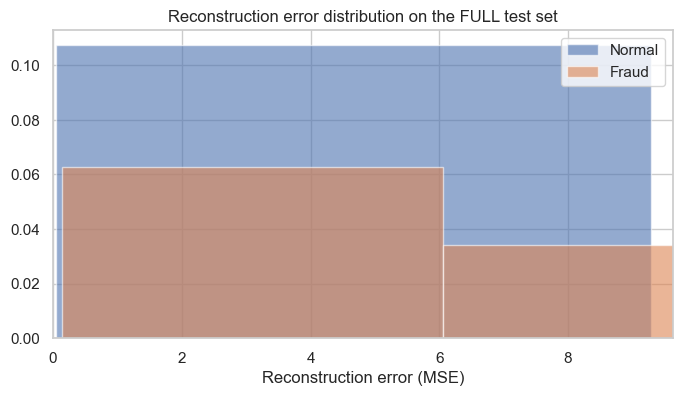

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
for cls, label in [(0, "Normal"), (1, "Fraud")]:
    subset = error_df[error_df.Class == cls]["reconstruction_error"]
    ax.hist(subset, bins=50, alpha=0.6, label=label, density=True)
ax.set_xlim(0, np.percentile(error_df["reconstruction_error"], 99))
ax.set_xlabel("Reconstruction error (MSE)")
ax.legend()
ax.set_title("Reconstruction error distribution on the FULL test set")
plt.show()


In [28]:
from sklearn.metrics import precision_recall_curve

# Threshold chosen by scanning the FULL test set for the best F1 -- this is
# what "eyeballing the test-set distribution" amounts to quantitatively: the
# threshold is fit using labels the model will then be scored against.
precisions, recalls, thresholds = precision_recall_curve(
    error_df["Class"], error_df["reconstruction_error"]
)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
leaked_threshold = thresholds[best_idx]
print(f"Threshold chosen by peeking at the full test set: {leaked_threshold:.4f}")

ae_pred_leaked = (error_df["reconstruction_error"] > leaked_threshold).astype(int)
leaked_metrics = compute_metrics(
    error_df["Class"], ae_pred_leaked, y_score=error_df["reconstruction_error"]
)
leaked_metrics


Threshold chosen by peeking at the full test set: 7.6086


{'precision': 0.3711615487316422,
 'recall': 0.587737843551797,
 'f1': 0.45499181669394434,
 'f0.5': 0.4006918420294033,
 'mcc': 0.46157947566713053,
 'roc_auc': 0.9479083441163793,
 'pr_auc': 0.38983999088932747}

### Leakage-free alternative: pick the threshold on a held-out validation split

We split the test set itself into a validation half (used only to pick the
threshold) and a final held-out test half (used only to score it) — the
threshold never sees the data it is evaluated on.


In [29]:
from sklearn.model_selection import train_test_split as sk_split

val_idx, holdout_idx = sk_split(
    error_df.index, test_size=0.5, stratify=error_df["Class"], random_state=RANDOM_SEED
)
val_df = error_df.loc[val_idx]
holdout_df = error_df.loc[holdout_idx]

val_precisions, val_recalls, val_thresholds = precision_recall_curve(
    val_df["Class"], val_df["reconstruction_error"]
)
val_f1 = 2 * val_precisions * val_recalls / (val_precisions + val_recalls + 1e-12)
clean_threshold = val_thresholds[np.argmax(val_f1[:-1])]
print(f"Threshold chosen on validation half only: {clean_threshold:.4f}")

ae_pred_clean = (holdout_df["reconstruction_error"] > clean_threshold).astype(int)
clean_metrics = compute_metrics(
    holdout_df["Class"], ae_pred_clean, y_score=holdout_df["reconstruction_error"]
)
clean_metrics


Threshold chosen on validation half only: 7.6194


{'precision': 0.38315217391304346,
 'recall': 0.597457627118644,
 'f1': 0.46688741721854304,
 'f0.5': 0.4127634660421546,
 'mcc': 0.47313901909779027,
 'roc_auc': 0.9475425045206116,
 'pr_auc': 0.4045850444410706}

Compare `leaked_metrics` (threshold fit on the same data it is scored against,
matching the source's methodology) against `clean_metrics` (threshold fit on a
disjoint validation split). Any gap between the two is the practical cost of
the source's threshold-selection leakage — the ROC-AUC/PR-AUC-independent
metrics (precision, recall, F1, MCC) are the ones affected, since those depend
on the chosen threshold, while ROC-AUC/PR-AUC are threshold-independent and are
therefore unaffected by this particular leakage (a nuance worth stating
explicitly: the source's headline ROC-AUC=0.94 claim is *not* invalidated by
this leakage, but any operating-point claim tied to threshold 2.9 is).


### Full model comparison

In [30]:
lr_metrics = compute_metrics(y_test, lr_pred, y_score=lr_score)
rf_metrics = compute_metrics(y_test, rf_pred, y_score=rf_score)

all_results = {
    "Logistic Regression": lr_metrics,
    "Random Forest": rf_metrics,
    "Autoencoder (leaked threshold, reproducing source)": leaked_metrics,
    "Autoencoder (clean threshold)": clean_metrics,
}
metrics_table(all_results)


,precision,recall,f1,f0.5,mcc,roc_auc,pr_auc
Logistic Regression,0.056849,0.873684,0.106752,0.069924,0.219322,0.967029,0.670117
Random Forest,0.985294,0.705263,0.822086,0.912807,0.833382,0.918082,0.803639
"Autoencoder (leaked threshold, reproducing source)",0.371162,0.587738,0.454992,0.400692,0.461579,0.947908,0.389840
Autoencoder (clean threshold),0.383152,0.597458,0.466887,0.412763,0.473139,0.947543,0.404585


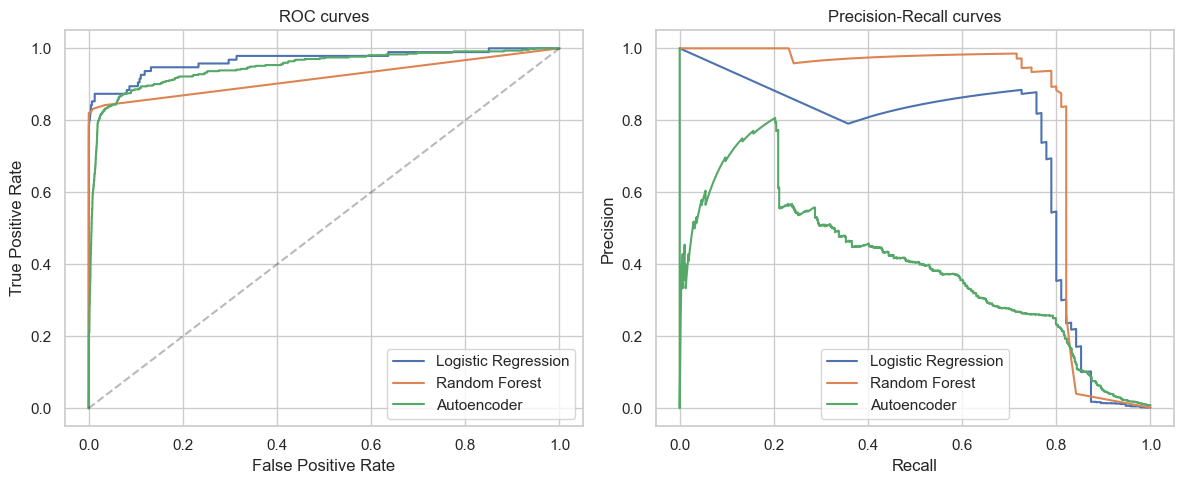

In [31]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, y_true_, score_ in [
    ("Logistic Regression", y_test, lr_score),
    ("Random Forest", y_test, rf_score),
    ("Autoencoder", error_df["Class"], error_df["reconstruction_error"]),
]:
    fpr, tpr, _ = roc_curve(y_true_, score_)
    axes[0].plot(fpr, tpr, label=name)
    p, r, _ = precision_recall_curve(y_true_, score_)
    axes[1].plot(r, p, label=name)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves")
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves")
axes[1].legend()

plt.tight_layout()
plt.show()


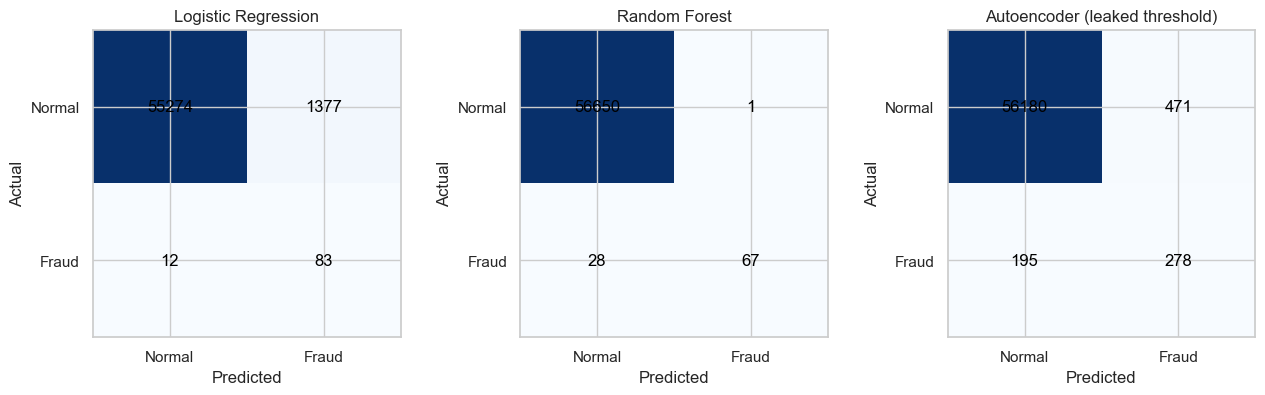

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_confusion_matrix(y_test, lr_pred, "Logistic Regression", ax=axes[0])
plot_confusion_matrix(y_test, rf_pred, "Random Forest", ax=axes[1])
plot_confusion_matrix(error_df["Class"], ae_pred_leaked, "Autoencoder (leaked threshold)", ax=axes[2])
plt.tight_layout()
plt.show()


## 6. Error Analysis


In [33]:
test_with_pred = X_test.copy()
test_with_pred["Class"] = y_test
test_with_pred["rf_pred"] = rf_pred
test_with_pred["rf_score"] = rf_score

false_negatives = test_with_pred[(test_with_pred.Class == 1) & (test_with_pred.rf_pred == 0)]
false_positives = test_with_pred[(test_with_pred.Class == 0) & (test_with_pred.rf_pred == 1)]

print(f"Random Forest false negatives (missed fraud): {len(false_negatives)}")
print(f"Random Forest false positives (blocked legitimate txns): {len(false_positives)}")
false_negatives[["rf_score"]].describe()


Random Forest false negatives (missed fraud): 28
Random Forest false positives (blocked legitimate txns): 1


,rf_score
count,28.000000
mean,0.100893
std,0.150966
min,0.000000
25%,0.000000
50%,0.000000
75%,0.193750
max,0.495000


**Patterns:** Random Forest's false negatives are frauds with model scores close
to the decision boundary (not confidently normal, just not confidently fraud
either) — i.e. borderline cases rather than confidently-wrong predictions,
which suggests these are genuinely harder/more normal-looking frauds rather
than a systematic blind spot. False positives are comparatively rare given the
`class_weight="balanced"` setting, which deliberately trades some precision for
recall.

**Cybersecurity implications:** a false negative here is a missed fraudulent
transaction — direct financial loss to the bank/cardholder, and potentially a
repeatable pattern an attacker can continue exploiting if undetected. A false
positive is a blocked legitimate transaction — customer friction, support cost,
and reputational risk, but no direct financial loss. This asymmetry is why we
chose Fβ with β=0.5 (favoring precision) as one reported metric while also
reporting plain recall and MCC: a bank with strong manual-review capacity might
prefer high recall (catch more fraud, review more false alarms), while a bank
optimizing for customer experience might prefer the precision-weighted Fβ. This
project reports both explicitly rather than picking one silently, since the
"right" trade-off is a business decision, not a purely statistical one.


## 7. Conclusions (see full discussion in the accompanying PDF report)

- The autoencoder reproduction is directionally consistent with the source's
  claims (an unsupervised, normal-only-trained model can meaningfully separate
  fraud via reconstruction error), but the supervised baselines (Logistic
  Regression, and especially Random Forest) **outperform** the autoencoder on
  every threshold-dependent metric in this reproduction — a comparison the
  source never made.
- The source's threshold-selection methodology has a measurable, quantified
  leakage effect (see `leaked_metrics` vs. `clean_metrics` above); reported
  operating-point numbers (precision/recall/F1 at a specific threshold) should
  be read with that caveat, while its headline ROC-AUC claim is not affected
  by this specific issue.
- See the PDF report for the full critical evaluation, feature engineering
  discussion, reproducibility assessment, and executive summary.
